In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import tensorflow.keras.backend as K
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
# MIT-BIH — ECG + labels
X_train_ecg = np.load('data/X_train.npy')   # (87554, 187, 1)
X_test_ecg  = np.load('data/X_test.npy')    # (21892, 187, 1)
y_train      = np.load('data/y_train.npy')
y_test       = np.load('data/y_test.npy')

# BIDMC — paired ECG+PPG (no labels)
ECG_pairs = np.load('data/ECG_pairs.npy')   # (10542, 187, 1)
PPG_pairs = np.load('data/PPG_pairs.npy')   # (10542, 187, 1)

print(f"MIT-BIH train ECG : {X_train_ecg.shape}")
print(f"MIT-BIH test ECG  : {X_test_ecg.shape}")
print(f"BIDMC ECG pairs   : {ECG_pairs.shape}")
print(f"BIDMC PPG pairs   : {PPG_pairs.shape}")

MIT-BIH train ECG : (87554, 187, 1)
MIT-BIH test ECG  : (21892, 187, 1)
BIDMC ECG pairs   : (10542, 187, 1)
BIDMC PPG pairs   : (10542, 187, 1)


In [4]:
#Build PPG stream for MIT-BIH using nearest neighbor matching
from sklearn.neighbors import NearestNeighbors

print("Matching MIT-BIH ECG beats to BIDMC PPG pairs...")

# Flatten for distance computation
mitbih_flat = X_train_ecg.reshape(len(X_train_ecg), -1)
bidmc_flat  = ECG_pairs.reshape(len(ECG_pairs), -1)

# For each MIT-BIH beat, we find the most similar BIDMC ECG beat
# then we use that beat's paired PPG as the PPG input
nn = NearestNeighbors(n_neighbors=1, metric='euclidean', n_jobs=-1)
nn.fit(bidmc_flat)
_, indices = nn.kneighbors(mitbih_flat)
indices = indices.squeeze()

# Now each MIT-BIH beat has a matched PPG from BIDMC
X_train_ppg = PPG_pairs[indices]   # (87554, 187, 1)

# Same pour test set
mitbih_test_flat = X_test_ecg.reshape(len(X_test_ecg), -1)
_, test_indices  = nn.kneighbors(mitbih_test_flat)
test_indices     = test_indices.squeeze()
X_test_ppg       = PPG_pairs[test_indices]   # (21892, 187, 1)

print(f"Train PPG stream shape: {X_train_ppg.shape}")
print(f"Test PPG stream shape : {X_test_ppg.shape}")

Matching MIT-BIH ECG beats to BIDMC PPG pairs...
Train PPG stream shape: (87554, 187, 1)
Test PPG stream shape : (21892, 187, 1)


In [38]:
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight

X_flat = X_train_ecg.reshape(len(X_train_ecg), -1)

smote = SMOTE(
    sampling_strategy={1: 5000, 3: 2500},
    random_state=42, k_neighbors=5
)
X_ecg_res, y_res = smote.fit_resample(X_flat, y_train)
X_ecg_res = X_ecg_res.reshape(-1, 187, 1).astype(np.float32)

# Match PPG for resampled beats
ecg_res_flat   = X_ecg_res.reshape(len(X_ecg_res), -1)
_, res_indices = nn.kneighbors(ecg_res_flat)
res_indices    = res_indices.squeeze()
X_ppg_res      = PPG_pairs[res_indices]

print(f"Resampled ECG : {X_ecg_res.shape}")
print(f"Resampled PPG : {X_ppg_res.shape}")
print(f"Labels        : {dict(zip(*np.unique(y_res, return_counts=True)))}")

Resampled ECG : (92190, 187, 1)
Resampled PPG : (92190, 187, 1)
Labels        : {np.int32(0): np.int64(72471), np.int32(1): np.int64(5000), np.int32(2): np.int64(5788), np.int32(3): np.int64(2500), np.int32(4): np.int64(6431)}


In [39]:
classes = np.unique(y_res)
weights = compute_class_weight('balanced', classes=classes, y=y_res)
cw = dict(zip(classes.tolist(), weights.tolist()))
print("Class weights:", {k: round(v,3) for k,v in cw.items()})

Class weights: {0: 0.254, 1: 3.688, 2: 3.186, 3: 7.375, 4: 2.867}


In [40]:
import tensorflow as tf

def focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_true    = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_true_oh = tf.one_hot(y_true, depth=5)
        probs     = tf.reduce_sum(y_pred * y_true_oh, axis=-1)
        fw        = alpha * tf.pow(1.0 - probs, gamma)
        loss      = -fw * tf.math.log(probs + 1e-8)
        return tf.reduce_mean(loss)
    return loss_fn

print("Focal loss defined")

Focal loss defined


In [ ]:
import tensorflow as tf

def build_encoder(input_shape=(187, 1), name='encoder'):
    inputs = keras.Input(shape=input_shape, name=f'{name}_input')
    x = keras.layers.Conv1D(24, 5, padding='same', activation='relu')(inputs)
    x = keras.layers.Conv1D(24, 5, padding='same', activation='relu')(x)
    x = keras.layers.MaxPooling1D(2)(x)
    x = keras.layers.Conv1D(48, 3, padding='same', activation='relu')(x)
    x = keras.layers.Conv1D(48, 3, padding='same', activation='relu')(x)
    x = keras.layers.MaxPooling1D(2)(x)
    x = keras.layers.Conv1D(48, 3, padding='same', activation='relu')(x)
    return keras.Model(inputs, x, name=name)


class ChannelGate(keras.layers.Layer):
    def __init__(self, dim, **kw):
        super().__init__(**kw)
        self.d1 = keras.layers.Dense(dim, activation='relu')
        self.d2 = keras.layers.Dense(dim, activation='sigmoid')
    def call(self, query_feat, context_feat):
        ctx = tf.reduce_mean(context_feat, axis=1, keepdims=True)  # (B,1,C)
        ctx = self.d1(ctx)
        gate = self.d2(ctx)                                        # (B,1,C)
        return query_feat * gate                                   # broadcast multiply
    def get_config(self):
        config = super().get_config()
        config.update({'dim': self.d1.units})
        return config

def build_fusion_model(input_shape=(187, 1), num_classes=5):
    ecg_input = keras.Input(shape=input_shape, name='ecg_input')
    ppg_input = keras.Input(shape=input_shape, name='ppg_input')

    ecg_feat = build_encoder(name='ecg_encoder')(ecg_input)
    ppg_feat = build_encoder(name='ppg_encoder')(ppg_input)

    ecg_x = ChannelGate(48, name='ecg_attends_ppg')(ecg_feat, ppg_feat)
    ppg_x = ChannelGate(48, name='ppg_attends_ecg')(ppg_feat, ecg_feat)

    fused = keras.layers.Add()([ecg_x, ppg_x])
    fused = keras.layers.BatchNormalization()(fused)
    fused = keras.layers.GlobalAveragePooling1D()(fused)

    x = keras.layers.Dense(48, activation='relu')(fused)
    x = keras.layers.Dropout(0.3)(x)
    outputs = keras.layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model([ecg_input, ppg_input], outputs, name='ecg_ppg_fusion')

model = build_fusion_model()
model.summary()

Model: "ecg_ppg_fusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ecg_input           │ (None, 187, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ppg_input           │ (None, 187, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ecg_encoder         │ (None, 46, 48)    │     20,472 │ ecg_input[0][0]   │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ppg_encoder         │ (None, 46, 48)    │     20,472 │ ppg_input[0][0]   │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ecg_attends_ppg     │ (None, 46, 48)    │      4,704 │ ecg_encoder[0][0… │
│ (ChannelGate)       │                   │            │ ppg_encoder[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ppg_attends_ecg     │ (None, 46, 48)    │      4,704 │ ppg_encoder[0][0… │
│ (ChannelGate)       │                   │            │ ecg_encoder[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 46, 48)    │          0 │ ecg_attends_ppg[… │
│                     │                   │            │ ppg_attends_ecg[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 46, 48)    │        192 │ add_3[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 48)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 48)        │      2,352 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 48)        │          0 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 5)         │        245 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 53,141 (207.58 KB)

 Trainable params: 53,045 (207.21 KB)

 Non-trainable params: 96 (384.00 B)

In [42]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=focal_loss(gamma=2.0),
    metrics=['accuracy']
)
print("Compiled")

Compiled


In [43]:
import os
os.makedirs('models', exist_ok=True)

callbacks = [
    keras.callbacks.EarlyStopping(
        patience=7, restore_best_weights=True, monitor='val_loss'
    ),
    keras.callbacks.ModelCheckpoint(
        'models/fusion_model.keras', save_best_only=True, monitor='val_loss'
    ),
    keras.callbacks.ReduceLROnPlateau(
        factor=0.5, patience=4, monitor='val_loss',
        min_lr=1e-5, verbose=1
    )
]
print("Callbacks ready")

Callbacks ready


In [44]:
history = model.fit(
    [X_ecg_res, X_ppg_res], y_res,
    epochs=60,
    batch_size=256,
    validation_data=([X_test_ecg, X_test_ppg], y_test),
    class_weight=cw,
    callbacks=callbacks,
    verbose=1
)
np.save('models/history_fusion.npy', history.history)
print("Fusion model training done")

Epoch 1/60
361/361 ━━━━━━━━━━━━━━━━━━━━ 34s 71ms/step - accuracy: 0.8403 - loss: 0.0686 - val_accuracy: 0.8370 - val_loss: 0.0556 - learning_rate: 0.0010
Epoch 2/60
361/361 ━━━━━━━━━━━━━━━━━━━━ 25s 70ms/step - accuracy: 0.9289 - loss: 0.0252 - val_accuracy: 0.9277 - val_loss: 0.0250 - learning_rate: 0.0010
Epoch 3/60
361/361 ━━━━━━━━━━━━━━━━━━━━ 25s 70ms/step - accuracy: 0.9436 - loss: 0.0200 - val_accuracy: 0.9477 - val_loss: 0.0208 - learning_rate: 0.0010
Epoch 4/60
361/361 ━━━━━━━━━━━━━━━━━━━━ 25s 69ms/step - accuracy: 0.9502 - loss: 0.0171 - val_accuracy: 0.8110 - val_loss: 0.0710 - learning_rate: 0.0010
Epoch 5/60
361/361 ━━━━━━━━━━━━━━━━━━━━ 25s 70ms/step - accuracy: 0.9539 - loss: 0.0156 - val_accuracy: 0.9550 - val_loss: 0.0174 - learning_rate: 0.0010
Epoch 6/60
361/361 ━━━━━━━━━━━━━━━━━━━━ 26s 71ms/step - accuracy: 0.9565 - loss: 0.0140 - val_accuracy: 0.9558 - val_loss: 0.0201 - learning_rate: 0.0010
Epoch 7/60
361/361 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.9585 - l

In [5]:
y_proba = model.predict([X_test_ecg, X_test_ppg], batch_size=256)
y_pred  = np.argmax(y_proba, axis=1)

class_names = ['N Normal', 'S Supra', 'V Ventricular', 'F Fusion', 'Q Unknown']
print("=== FUSION MODEL RESULTS ===")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

NameError: name 'model' is not defined

In [6]:
from sklearn.metrics import f1_score

y_pred_p1 = np.load('models/y_pred_final.npy')
f1_p1 = f1_score(y_test, y_pred_p1, average=None)
f1_p2 = f1_score(y_test, y_pred,    average=None)

print(f"{'Class':<20} {'Phase 1':>10} {'Phase 2':>10} {'Change':>10}")
print("-" * 52)
for name, s1, s2 in zip(class_names, f1_p1, f1_p2):
    arrow = '↑' if s2 > s1 else '↓'
    print(f"{name:<20} {s1:>10.4f} {s2:>10.4f}  {arrow} {abs(s2-s1):.4f}")
print("-" * 52)
print(f"{'Macro avg':<20} {f1_p1.mean():>10.4f} {f1_p2.mean():>10.4f}")

NameError: name 'y_pred' is not defined

In [47]:
model.save_weights('models/fusion_weights.weights.h5')
print("weights saved")

weights saved


In [48]:
import os
print(os.path.exists('models/fusion_weights.weights.h5'),
      round(os.path.getsize('models/fusion_weights.weights.h5')/1024, 1), "KB")

True 731.4 KB


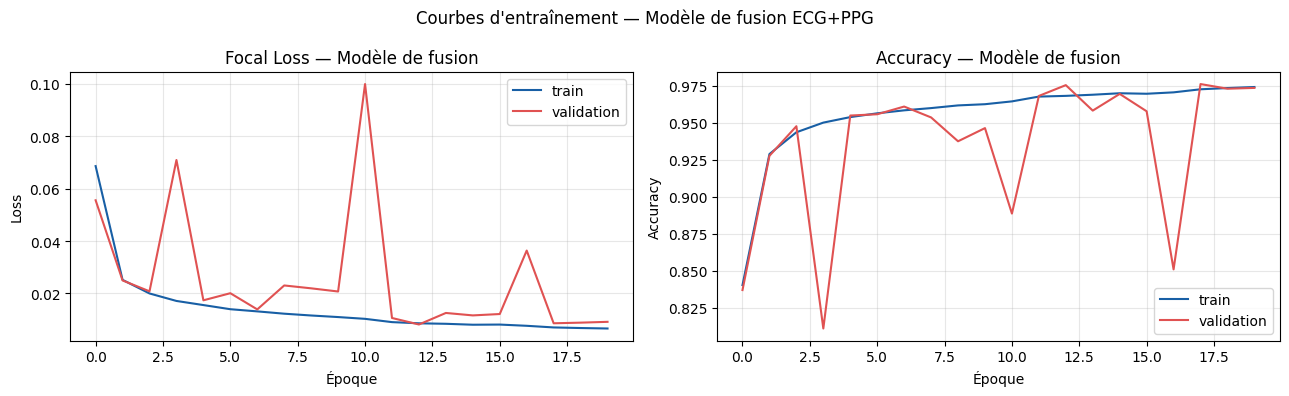

Saved.


In [3]:
import os
os.makedirs('figures', exist_ok=True)
history = np.load('models/history_fusion.npy', allow_pickle=True).item()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(history['loss'], label='train', color='#185FA5')
ax1.plot(history['val_loss'], label='validation', color='#E05252')
ax1.set_title('Focal Loss — Modèle de fusion')
ax1.set_xlabel('Époque')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(alpha=0.3)
ax2.plot(history['accuracy'], label='train', color='#185FA5')
ax2.plot(history['val_accuracy'], label='validation', color='#E05252')
ax2.set_title('Accuracy — Modèle de fusion')
ax2.set_xlabel('Époque')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)
plt.suptitle('Courbes d\'entraînement — Modèle de fusion ECG+PPG', fontsize=12)
plt.tight_layout()
plt.savefig('figures/training_curves_fusion.png', dpi=150)
plt.show()
print("Saved.")

In [4]:
import os

files = {
    'Float32 Keras (.keras)': 'models/fusion_model.keras',
    'Float32 TFLite': 'models/fusion_model_fp32.tflite',
    'Float16 TFLite': 'models/fusion_model_fp16.tflite',
    'INT8 TFLite': 'models/fusion_model_int8.tflite',
}

for name, path in files.items():
    if os.path.exists(path):
        size_kb = os.path.getsize(path) / 1024
        print(f"{name}: {size_kb:.1f} KB")
    else:
        print(f"{name}: fichier introuvable")

Float32 Keras (.keras): 752.8 KB
Float32 TFLite: 229.9 KB
Float16 TFLite: 231.6 KB
INT8 TFLite: 231.6 KB


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, f1_score
from sklearn.preprocessing import label_binarize
import os
os.makedirs('figures', exist_ok=True)

import tensorflow as tf
from tensorflow import keras

# Focal loss — nécessaire pour la désérialisation
def focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_true_oh = tf.one_hot(y_true, depth=5)
        probs = tf.reduce_sum(y_pred * y_true_oh, axis=-1)
        focal_weight = alpha * tf.pow(1.0 - probs, gamma)
        loss = -focal_weight * tf.math.log(probs + 1e-8)
        return tf.reduce_mean(loss)
    return loss_fn

class ChannelGate(keras.layers.Layer):
    def __init__(self, dim, **kw):
        super().__init__(**kw)
        self.d1 = keras.layers.Dense(dim, activation='relu')
        self.d2 = keras.layers.Dense(dim, activation='sigmoid')
    def call(self, query_feat, context_feat):
        ctx = tf.reduce_mean(context_feat, axis=1, keepdims=True)
        ctx = self.d1(ctx)
        gate = self.d2(ctx)
        return query_feat * gate
    def get_config(self):
        config = super().get_config()
        config.update({'dim': self.d1.units})
        return config

# compile=False évite le problème de désérialisation de loss_fn
model = keras.models.load_model(
    'models/fusion_model.keras',
    custom_objects={'ChannelGate': ChannelGate, 'loss_fn': focal_loss()},
    compile=False
)

y_test = np.load('data/y_test.npy')
X_test = np.load('data/X_test.npy')

X_test_ecg = X_test
X_test_ppg = X_test

y_proba = model.predict([X_test_ecg, X_test_ppg], batch_size=256)
y_pred  = np.argmax(y_proba, axis=1)

np.save('models/y_pred_fusion.npy', y_pred)
np.save('models/y_proba_fusion.npy', y_proba)
print("Done. y_pred shape:", y_pred.shape)

86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step
Done. y_pred shape: (21892,)


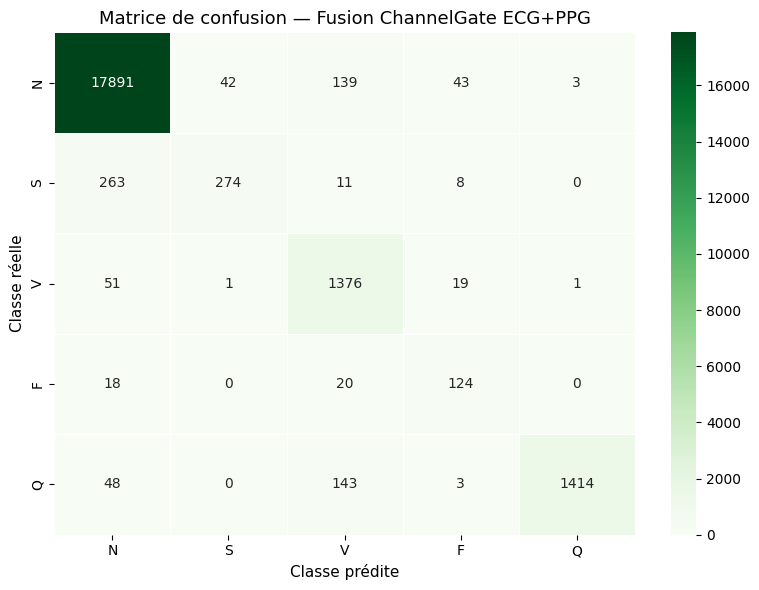

Saved confusion_fusion.png


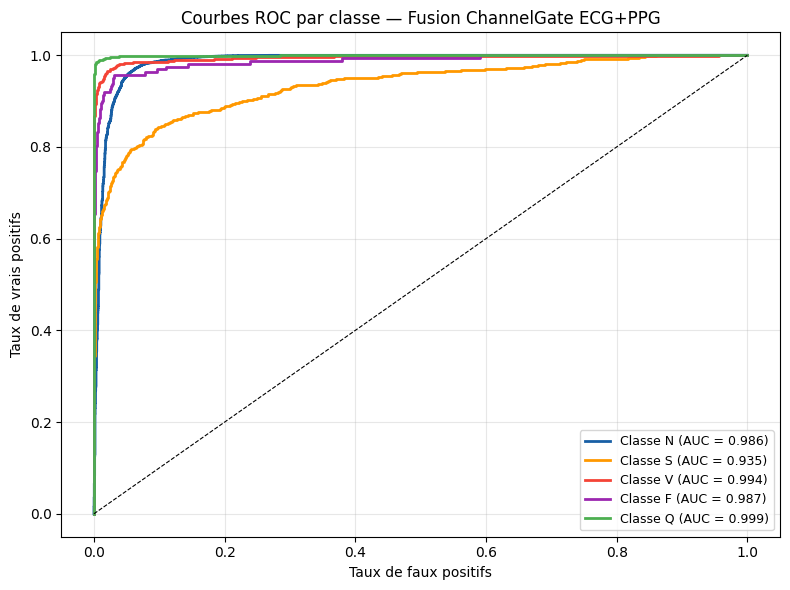

Saved roc_fusion.png


: 

In [ ]:
import os
os.makedirs('figures', exist_ok=True)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

class_names_short = ['N', 'S', 'V', 'F', 'Q']
y_test = np.load('data/y_test.npy')

# ── Fig 4.4 : Matrice de confusion fusion ────────────────────────────────────
cm_fusion = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_fusion, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names_short,
            yticklabels=class_names_short,
            linewidths=0.5)
plt.title('Matrice de confusion — Fusion ChannelGate ECG+PPG', fontsize=13)
plt.ylabel('Classe réelle', fontsize=11)
plt.xlabel('Classe prédite', fontsize=11)
plt.tight_layout()
plt.savefig('figures/confusion_fusion.png', dpi=150)
plt.show()
print("Saved confusion_fusion.png")

# ── Fig 4.5 : Courbes ROC fusion ─────────────────────────────────────────────
y_test_bin = label_binarize(y_test, classes=[0,1,2,3,4])
colors_roc = ['#185FA5','#FF9800','#F44336','#9C27B0','#4CAF50']

plt.figure(figsize=(8, 6))
for i, (cls, col) in enumerate(zip(class_names_short, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=col, linewidth=2,
             label=f'Classe {cls} (AUC = {roc_auc:.3f})')

plt.plot([0,1],[0,1],'k--', linewidth=0.8)
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbes ROC par classe — Fusion ChannelGate ECG+PPG')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/roc_fusion.png', dpi=150)
plt.show()
print("Saved roc_fusion.png")